# Proyecto final

In [23]:
# Librerias estandar
import pandas as pd
import numpy as np
import datasets 
import os
from tqdm.notebook import tqdm
import sklearn 
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


# Librerias preprocesamiento
import spacy
from afinn import Afinn
afinn_dict = Afinn(language='en')._dict
import gensim.downloader as api

# Torch
from utils import TextClassifierRNN
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



# Extra
import utils
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Datos 

In [6]:
dataset = datasets.load_dataset("sh0416/ag_news")
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

In [7]:
train = pd.DataFrame(dataset["train"])
test = pd.DataFrame(dataset["test"])

print(f"Dimensiones train: {train.shape}")
print(f"Dimensiones test: {test.shape}")

print(f"\nTrain:")
train.sample(5)

Dimensiones train: (120000, 3)
Dimensiones test: (7600, 3)

Train:


,label,title,description
106742,2,Knicks Grind Up Slumping Grizzlies 90-82 (AP),AP - Stephon Marbury made five 3-pointers in t...
84262,3,Honda to invest US\$340 million to boost auto ...,TOKYO : Japanese automaker Honda is to spend 3...
118296,3,Fannie Mae Pays the Price of Cutting Corners t...,Fannie Mae wanted to look very safe. But to do...
35616,3,Oil hits \$47 as supply worries,LONDON - Oil prices hit \$47 a barrel yesterda...
70195,1,"Japan Quake Kills 18, Aftershocks Strike Fear","OJIYA, Japan (Reuters) - Strong aftershocks s..."


## Ejercicio 1

Utilizando AG News, se deberán implementar y comparar varios sistemas y enfoques vistos a lo largo de la 
asignatura. En este ejercicio, la entrada del sistema deberá ser únicamente la columna **description**. La 
columna **title** **no** deberá utilizarse como parte del texto de entrada para clasificar.

In [8]:
# Seleccionamos lo necesario para este ejercicio
X_train = pd.DataFrame(train["description"])
y_train = pd.DataFrame(train["label"])

X_test = pd.DataFrame(test["description"])
y_test = pd.DataFrame(test["label"])

results_dict = {}

### Clasificación mediante lexicón

En primer lugar se va a utilizar un lexicón para hacer un análisis simple de sentimientos, calculando la puntuación de cada texto y clasificando utilizando el cero de umbral. Es el método más sencillo para clasificar y, por tanto, el que peores resultados debería tener. En este caso no se utilizará el conjunto de train, puesto que el modelo no requiere entrenamiento alguno.

In [9]:
# Inicializar spaCy 
try:
    # Intentar cargar el modelo
    print(f"Modelo ya desargado")
    nlp = spacy.load("en_core_web_sm")
    print(f"Modelo cargado")
except OSError:
    # Descargar si es necesario
    print(f"Descargando modelo...")
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")
    print(f"Modelo cargado")
    
nlp = spacy.load("en_core_web_sm")

true_positives = 0

# Iteramos sobre cada texto 
for text in tqdm(X_test["description"].values, desc="Procesando textos"):
    # Tokenizar con spaCy
    doc = nlp(text)
    
    # Filtrar stopwords y puntuaciones, y obtener los strings limpios
    tokens_limpios = [token.text.lower() for token in doc if not token.is_stop and not token.is_punct]
    
    # Sustituir cada string por su valor en el diccionario de AFINN (0 si no existe)
    valores_afinn = [afinn_dict.get(word, 0) for word in tokens_limpios]
    
    # Pasar a np.array y realizar la suma
    suma = np.array(valores_afinn).sum()
    
    # Condición solicitada
    if suma >= 0:
        true_positives += 1

print(f"Accuracy: {true_positives/len(X_test)}")

results_dict["lexicon"] = true_positives/len(X_test)

Modelo ya desargado
Modelo cargado


Procesando textos:   0%|          | 0/7600 [00:00<?, ?it/s]

Accuracy: 0.6227631578947368


### Preprocesados textuales

Para los próximos modelos es esencial el pre-procesamiento de los textos. Para ello, se tokenizaran de cuatro formas distintas:

1. Tokenizacion 

2. Tokenización sin puntuaciones.

3. Tokenización sin stopwords.

4. Tokenizacion sin puntuaciones y sin stopwords.

In [10]:
# Ruta de datos 
data_dir = ".data"
os.makedirs(data_dir, exist_ok=True)

# Rutas a los diferents parquet
ficheros_train = [os.path.join(data_dir, f"X_train_{i}.parquet") for i in range(1, 5)]
ficheros_test = [os.path.join(data_dir, f"X_test_{i}.parquet") for i in range(1, 5)]

# Intentamos leer los datos si ya los tenemos guardados 
try:
    print("Intentando cargar las matrices optimizadas desde disco...")
    
    # Leemos y separamos en tokens
    X_train_1 = pd.read_parquet(ficheros_train[0]).iloc[:, 0].str.split()
    X_train_2 = pd.read_parquet(ficheros_train[1]).iloc[:, 0].str.split()
    X_train_3 = pd.read_parquet(ficheros_train[2]).iloc[:, 0].str.split()
    X_train_4 = pd.read_parquet(ficheros_train[3]).iloc[:, 0].str.split()

    X_test_1 = pd.read_parquet(ficheros_test[0]).iloc[:, 0].str.split()
    X_test_2 = pd.read_parquet(ficheros_test[1]).iloc[:, 0].str.split()
    X_test_3 = pd.read_parquet(ficheros_test[2]).iloc[:, 0].str.split()
    X_test_4 = pd.read_parquet(ficheros_test[3]).iloc[:, 0].str.split()
    print("Matrices cargadas y convertidas a listas de tokens correctamente.")

except (FileNotFoundError, Exception):
    print("Ficheros no encontrados o corruptos. Iniciando procesamiento con spaCy...")
    
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

    # Generar las matrices (devuelve Series de strings separados por espacios)
    X_train_1, X_train_2, X_train_3, X_train_4 = utils.procesar_matrices(X_train["description"], nlp)
    X_test_1, X_test_2, X_test_3, X_test_4 = utils.procesar_matrices(X_test["description"], nlp)

    print("Guardando matrices procesadas en formato Parquet...")
    # Guardamos el texto plano en el Parquet, es mas eficiente
    pd.DataFrame(X_train_1).to_parquet(ficheros_train[0])
    pd.DataFrame(X_train_2).to_parquet(ficheros_train[1])
    pd.DataFrame(X_train_3).to_parquet(ficheros_train[2])
    pd.DataFrame(X_train_4).to_parquet(ficheros_train[3])

    pd.DataFrame(X_test_1).to_parquet(ficheros_test[0])
    pd.DataFrame(X_test_2).to_parquet(ficheros_test[1])
    pd.DataFrame(X_test_3).to_parquet(ficheros_test[2])
    pd.DataFrame(X_test_4).to_parquet(ficheros_test[3])

    # Convertir las Series de strings a listas de tokens
    X_train_1, X_train_2, X_train_3, X_train_4 = X_train_1.str.split(), X_train_2.str.split(), X_train_3.str.split(), X_train_4.str.split()
    X_test_1, X_test_2, X_test_3, X_test_4 = X_test_1.str.split(), X_test_2.str.split(), X_test_3.str.split(), X_test_4.str.split()
    print("Proceso finalizado con éxito.")

Intentando cargar las matrices optimizadas desde disco...
Matrices cargadas y convertidas a listas de tokens correctamente.


In [11]:
X_train_dict = {
    "1": X_train_1,
    "2": X_train_2,
    "3": X_train_3,
    "4": X_train_4
}

X_test_dict = {
    "1": X_test_1,
    "2": X_test_2,
    "3": X_test_3,
    "4": X_test_4
}

In [12]:
print(f"Vamos a ver, para el primer documento de train, la diferencia de numero de tokens:\n"
      f" - Tokenizacion simple: {len(X_train_1[0])}\n"
      f" - Tokenizacion sin puntuaciones: {len(X_train_2[0])}\n"
      f" - Tokenizacion sin stopwords: {len(X_train_3[0])}\n"
      f" - Tokenizacion sin ambas: {len(X_train_4[0])}\n")

Vamos a ver, para el primer documento de train, la diferencia de numero de tokens:
 - Tokenizacion simple: 20
 - Tokenizacion sin puntuaciones: 14
 - Tokenizacion sin stopwords: 16
 - Tokenizacion sin ambas: 10



Hecho esto, ahora se tienen 4 dataframes por cada tipo de tokenización. La idea es comparar el desempeño de estos cuatro pre-procesamientos a la hora de clasificar. Se utilizarán tanto para la parte de representaciones dispersas y densas (machine learning tradicional) como para fine-tuninig (transformers).

### Representaciones dispersas y densas

#### Dispersas

Para las representaciones dispersas los modelos a probar son; Naives Bayes, regresión logística y SVM.

In [13]:
# Inicializar los diccionarios donde se guardarán las matrices BoW
X_train_BoW = {}
X_test_BoW = {}

# Iterar sobre las 4 configuraciones de tus datos
for key in tqdm(X_train_dict.keys(), desc="Vectorizando matrices BoW"):
    # Instanciar el vectorizador configurado para listas de tokens
    vectorizer = sklearn.feature_extraction.text.CountVectorizer(analyzer=lambda x: x, lowercase=False)
    
    # AJUSTAR y transformar con el conjunto de TRAIN
    X_train_BoW[key] = vectorizer.fit_transform(X_train_dict[key])
    
    # TRANSFORMAR el conjunto de TEST usando solo el vocabulario aprendido de TRAIN
    X_test_BoW[key] = vectorizer.transform(X_test_dict[key])

Vectorizando matrices BoW:   0%|          | 0/4 [00:00<?, ?it/s]

In [14]:
# Definimos hiperparametros para los ditintos modelos
models_and_params = {
    "NaiveBayes": {
        "model": MultinomialNB(),
        "params": {"alpha": [0.1, 1.0]}
    },
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=200, solver="saga", tol=0.1), 
        "params": {"C": [0.1, 1.0]}
    },
    "SVM": {
        # dual=False es más rápido cuando n_samples > n_features
        "model": LinearSVC(max_iter=500, dual=False, tol=1e-3), 
        "params": {"C": [0.1, 1.0]}
    }
}

# Diccionario para almacenar los mejores modelos resultantes
best_models = {}

# Aplanar por seguridad
y_test_flat = y_test.values

for matrix_key in tqdm(X_train_BoW.keys(), desc="Evaluating text configurations"):
    X_train = X_train_BoW[matrix_key]
    # Extraer la matriz de test correspondiente a la configuración actual
    X_test_mat = X_test_BoW[matrix_key]
    y_train_flat = y_train.values.ravel()
    
    best_models[matrix_key] = {}
    
    # Bucle interno: itera sobre los modelos definidos
    for model_name, config in tqdm(models_and_params.items(), desc=f"GridSearch on Matrix {matrix_key}", leave=False):
        
        # Iniciar el cronómetro para este modelo
        start_time = time.time()
        
        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=3,
            scoring="accuracy",
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train_flat)
        
        # Guardar el mejor modelo entrenado
        best_model = grid.best_estimator_
        best_models[matrix_key][model_name] = best_model
        
        # Calcular el accuracy real utilizando el conjunto de test
        test_accuracy = best_model.score(X_test_mat, y_test_flat)
        
        # Calcular el tiempo transcurrido en segundos
        elapsed_time = time.time() - start_time
        
        # Guardar el accuracy de test con la nomenclatura solicitada
        key_name = f"{model_name}_{matrix_key}_BoW"
        results_dict[key_name] = float(test_accuracy)
        
        tqdm.write(f"-> Matrix {matrix_key} | {model_name} | Best Params: {grid.best_params_} | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s")

Evaluating text configurations:   0%|          | 0/4 [00:00<?, ?it/s]

GridSearch on Matrix 1:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 1 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8962 | Time: 1.56s
-> Matrix 1 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8830 | Time: 2.79s
-> Matrix 1 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9125 | Time: 48.28s


GridSearch on Matrix 2:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 2 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8949 | Time: 0.28s
-> Matrix 2 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8932 | Time: 1.17s
-> Matrix 2 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9086 | Time: 40.38s


GridSearch on Matrix 3:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 3 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8955 | Time: 0.26s
-> Matrix 3 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8834 | Time: 1.29s
-> Matrix 3 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9113 | Time: 25.94s


GridSearch on Matrix 4:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 4 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8951 | Time: 0.26s
-> Matrix 4 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.8970 | Time: 0.97s
-> Matrix 4 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9079 | Time: 18.83s


In [15]:
# Inicializar los diccionarios donde se guardarán las matrices TF-IDF
X_train_TFIDF = {}
X_test_TFIDF = {}

# Iterar sobre las 4 configuraciones de tus datos
for key in tqdm(X_train_dict.keys(), desc="Vectorizing TF-IDF matrices"):
    # Instanciar el vectorizador configurado para listas de tokens
    vectorizer = TfidfVectorizer(analyzer=lambda x: x, lowercase=False)
    
    # AJUSTAR y transformar con el conjunto de TRAIN
    X_train_TFIDF[key] = vectorizer.fit_transform(X_train_dict[key])
    
    # TRANSFORMAR el conjunto de TEST usando solo el vocabulario aprendido de TRAIN
    X_test_TFIDF[key] = vectorizer.transform(X_test_dict[key])

Vectorizing TF-IDF matrices:   0%|          | 0/4 [00:00<?, ?it/s]

In [16]:
# Diccionario para almacenar los mejores modelos resultantes de TF-IDF
best_models_tfidf = {}

# Asegurar que sea plano
y_test_flat = y_test.values.ravel()

# Bucle exterior: iterar por matriz 
for matrix_key in tqdm(X_train_TFIDF.keys(), desc="Evaluating TF-IDF configurations"):
    X_train = X_train_TFIDF[matrix_key]
    # Extraer la matriz de test correspondiente a la configuración actual
    X_test_mat = X_test_TFIDF[matrix_key]
    y_train_flat = y_train.values.ravel()
    
    best_models_tfidf[matrix_key] = {}
    
    # Bucle interior: iterar sobre los modelos
    for model_name, config in tqdm(models_and_params.items(), desc=f"GridSearch on TF-IDF Matrix {matrix_key}", leave=False):
        
        # Iniciar el cronómetro para este modelo
        start_time = time.time()
        
        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=3,
            scoring="accuracy",
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train_flat)
        
        # Guardar el mejor modelo entrenado
        best_model = grid.best_estimator_
        best_models_tfidf[matrix_key][model_name] = best_model
        
        # Calcular el accuracy real utilizando el conjunto de test
        test_accuracy = best_model.score(X_test_mat, y_test_flat)
        
        # Calcular el tiempo transcurrido en segundos
        elapsed_time = time.time() - start_time
        
        # Guardar el accuracy con la nomenclatura solicitada para TF-IDF
        key_name = f"{model_name}_{matrix_key}_TFIDF"
        results_dict[key_name] = float(test_accuracy)
        
        tqdm.write(f"-> Matrix {matrix_key} | {model_name} | Best Params: {grid.best_params_} | Test Accuracy: {test_accuracy:.4f} | Time: {elapsed_time:.2f}s")

Evaluating TF-IDF configurations:   0%|          | 0/4 [00:00<?, ?it/s]

GridSearch on TF-IDF Matrix 1:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 1 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8982 | Time: 0.28s
-> Matrix 1 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9097 | Time: 1.17s
-> Matrix 1 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9100 | Time: 12.13s


GridSearch on TF-IDF Matrix 2:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 2 | NaiveBayes | Best Params: {'alpha': 0.1} | Test Accuracy: 0.8971 | Time: 0.26s
-> Matrix 2 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9053 | Time: 1.05s
-> Matrix 2 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9087 | Time: 10.58s


GridSearch on TF-IDF Matrix 3:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 3 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8957 | Time: 0.25s
-> Matrix 3 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9013 | Time: 0.96s
-> Matrix 3 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9088 | Time: 8.89s


GridSearch on TF-IDF Matrix 4:   0%|          | 0/3 [00:00<?, ?it/s]

-> Matrix 4 | NaiveBayes | Best Params: {'alpha': 1.0} | Test Accuracy: 0.8947 | Time: 0.25s
-> Matrix 4 | LogisticRegression | Best Params: {'C': 1.0} | Test Accuracy: 0.9054 | Time: 0.90s
-> Matrix 4 | SVM | Best Params: {'C': 0.1} | Test Accuracy: 0.9084 | Time: 7.60s


Para todos los tipos de tokenización se puede observar que los resultados son básicamente idénticos. Sin embargo, los tiempos de entrenamiento varian muy considerablemente. En primer lugar, se puede ver como usar la matriz cuatro (sin puntuaciones y sin stopwords), si bien no incrementa la precision, baja mucho el tiempo de entrenamiento, es decir, que esa "informacion extra" que eliminamos es, para este dataset, inutil, por lo que se selecciona esta. 

Por otro lado, haciendo la comparación BoW vs TF-IDF, si bien no hay diferencias significativas de accuracy, si lo hay también en tiempos. A pesar de que a priori podría parecer que ambas son igual de buenas, dicha diferencia de tiempos nos sugiere lo contrario, ya que en ambas representaciones el tamaño de las matrices son iguales, por lo que un menor tiempo de entrenamiento implica una convergencia más rapida, lo que a su vez sugiere que la representación de los textos es mucho más informativa.

Por último, los tres tipos de modelos propuestos son igual de precisos en este dataset, pero el desempate se ve por tiempo de ejecución, donde Naives Bayes domina a los otros dos (sobre todo a SVM).

Antes de pasar con las densas, vamos a visualizar los resultados para que todo quede más claro, pero solo con los resultados de matriz 4, que se ha visto que es la representación más interesante.

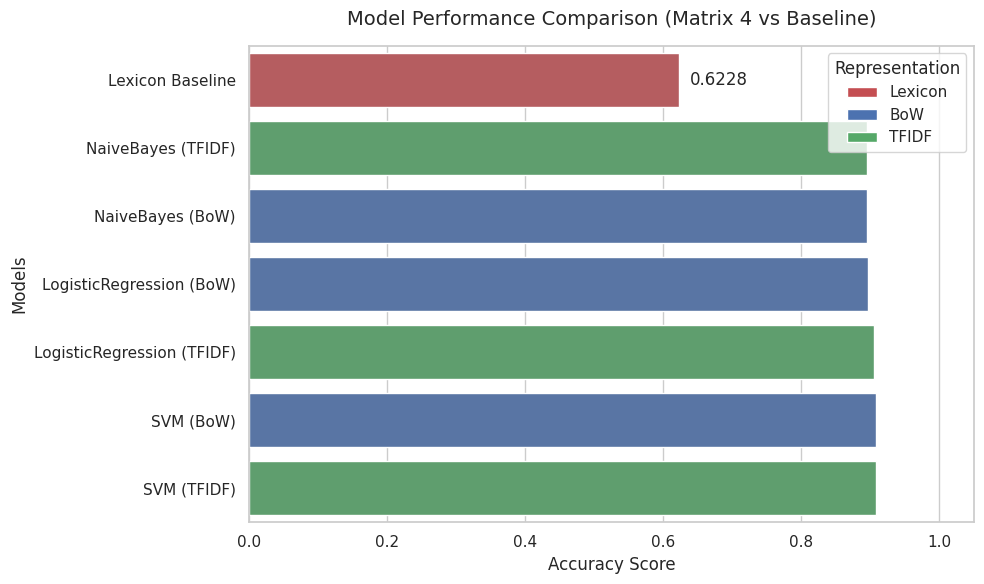

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Filtrar el diccionario y construir una estructura de datos limpia
plot_data = []

for key, accuracy in results_dict.items():
    if key == "lexicon":
        plot_data.append(
            {
                "Model_Matrix": "Lexicon Baseline",
                "Accuracy": accuracy,
                "Representation": "Lexicon",
            }
        )
    elif "_4_" in key:
        model_name = key.split("_")[0]
        representation = "BoW" if "BoW" in key else "TFIDF"

        plot_data.append(
            {
                "Model_Matrix": f"{model_name} ({representation})",
                "Accuracy": accuracy,
                "Representation": representation,
            }
        )

# Convertir a DataFrame de Pandas
df_plot = pd.DataFrame(plot_data)

# Ordenar por Accuracy para mejorar la lectura visual del gráfico
df_plot = df_plot.sort_values(by="Accuracy", ascending=True)

# 2. Configurar el estilo y los colores estáticos por fila
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Diccionario de colores asignados por tipo de representación
color_map = {"BoW": "#4C72B0", "TFIDF": "#55A868", "Lexicon": "#C44E52"}
# Crear una lista de colores emparejada uno a uno con el orden de las filas del DataFrame
bar_colors = [color_map[rep] for rep in df_plot["Representation"]]

# 3. Crear el gráfico de barras horizontales (sin hue para evitar duplicar textos)
ax = sns.barplot(
    x="Accuracy",
    y="Model_Matrix",
    data=df_plot,
    palette=bar_colors,  # Pasamos la lista exacta de colores asignados
)

# Ajustar límites del eje X
ax.set_xlim(0.0, 1.05)  # Un poco más de 1.0 para dar margen a la última etiqueta
ax.set_xlabel("Accuracy Score")
ax.set_ylabel("Models")
ax.set_title(
    "Model Performance Comparison (Matrix 4 vs Baseline)",
    fontsize=14,
    pad=15,
)

# Añadir las etiquetas de valor numérico sin duplicados
ax.bar_label(ax.containers[0], fmt="%.4f", padding=8)

# Añadir manualmente una leyenda dummy para mantener la referencia de colores
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#C44E52", label="Lexicon"),
    Patch(facecolor="#4C72B0", label="BoW"),
    Patch(facecolor="#55A868", label="TFIDF"),
]
ax.legend(handles=legend_elements, title="Representation", loc="upper right")

plt.tight_layout()
plt.show()

Aqui ya se aprecia bien como no hay diferencias ni por modelo ni por tipo de representacion dispersa para estos modelos y este dataset.

#### Densas

Para las representaciones densas los modelos a probar son; regresión logística, SVM, LSTM estándar y GRU. 

En primer lugar, vamos a codificar los tokens por vocabulario.

In [22]:
# Diccionarios para almacenar las secuencias indexadas y con padding
X_train_seq = {}
X_test_seq = {}
vocabularies = {}  # Guardará el vocabulario asociado a cada configuración

# Calcular dinámicamente el tamaño máximo de secuencia sumando train y test
max_train = max(len(tokens) for tokens in X_train_dict["1"])
max_test = max(len(tokens) for tokens in X_test_dict["1"])
MAX_LEN = max(max_train, max_test)

# Construir el vocabulario
word_counts = Counter()
for tokens in X_train_dict["1"]:
    word_counts.update(tokens)

# Creamos el mapeo de palabra -> índice
# Reservamos el 0 para el Padding y el 1 para palabras desconocidas (OOV)
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in word_counts.items():
    vocab[word] = len(vocab)


# Función para indexar y aplicar padding/truncating a las secuencias
def encode_and_pad(token_lists, vocabulary, max_len):
    encoded_matrices = []
    for tokens in token_lists:
        # Convertir tokens a índices (usar 1 si no existe en el vocabulario de train)
        indices = [vocabulary.get(token, 1) for token in tokens]

        # Aplicar Truncating si excede max_len
        if len(indices) > max_len:
            indices = indices[:max_len]
        # Aplicar Padding con ceros si es más corto
        else:
            indices = indices + [0] * (max_len - len(indices))

        encoded_matrices.append(indices)
    return np.array(encoded_matrices, dtype=np.int64)


# Transformar los conjuntos de TRAIN y TEST para la matriz 1
X_train_seq = encode_and_pad(X_train_dict["1"], vocab, MAX_LEN)
X_test_seq = encode_and_pad(X_test_dict["1"], vocab, MAX_LEN)

print(
    f"Tamaños de secuencia:\n - Train: {X_train_seq.shape}\n - Test: {X_test_seq.shape}"
)

Tamaños de secuencia:
 - Train: (120000, 199)
 - Test: (7600, 199)


Codificación lista, ahora toca obtener los embeddings estaticos. Para esta tarea se van a utilizar GloVe y FastText. 

In [24]:
# Descargar los modelos preentrenados a través de gensim
print("Descargando vectores de GloVe...")
glove_model = api.load("glove-wiki-gigaword-100")

print("Descargando vectores de FastText...")
fasttext_model = api.load("fasttext-wiki-news-subwords-300")

# Dimensiones correspondientes a cada modelo descargado
embedding_dim_glove = 100
embedding_dim_fasttext = 300

# Inicializar las matrices de pesos con ceros
glove_matrix = np.zeros((len(vocab), embedding_dim_glove), dtype=np.float32)
fasttext_matrix = np.zeros(
    (len(vocab), embedding_dim_fasttext), dtype=np.float32
)

# Rellenar las matrices con los vectores del vocabulario aprendido en train
for word, idx in vocab.items():
    if word in ["<PAD>", "<UNK>"]:
        continue

    if word in glove_model:
        glove_matrix[idx] = glove_model[word]

    if word in fasttext_model:
        fasttext_matrix[idx] = fasttext_model[word]

Descargando vectores de GloVe...
[==================================================] 100.0% 128.1/128.1MB downloaded
Descargando vectores de FastText...
[==================================================] 100.0% 958.5/958.4MB downloaded


### Fine-tuning de modelos basados en transformers

### Clasificación utilizando LLMs y promting

### Resultados

## Ejercicio 2